# 01 — Exploratory Data Analysis
**Redrob Hackathon — Candidate Pool (100K)**

Run this once. Understand the data before writing any scoring logic.

Sections:
1. Load & basic stats
2. Geography
3. Titles & role distribution
4. Skills analysis
5. Career background
6. Behavioral signals
7. Honeypot detection
8. Keyword stuffer analysis
9. Good candidate pool
10. Key takeaways

In [1]:
import json
import os
import warnings
from collections import Counter, defaultdict
from datetime import datetime

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import pandas as pd
import numpy as np

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

CURRENT_DATE = datetime(2026, 6, 5)
DATA_PATH    = os.path.join('..', 'candidates.jsonl')

print('Libraries loaded.')

Libraries loaded.


---
## 1. Load & Basic Stats

In [2]:
candidates = []
with open(DATA_PATH, 'r', encoding='utf-8') as f:
    for line in f:
        candidates.append(json.loads(line))

print(f'Total candidates loaded: {len(candidates):,}')
print(f'\nSample keys: {list(candidates[0].keys())}')
print(f'Profile keys: {list(candidates[0]["profile"].keys())}')
print(f'Signal keys: {list(candidates[0]["redrob_signals"].keys())}')

Total candidates loaded: 100,000

Sample keys: ['candidate_id', 'profile', 'career_history', 'education', 'skills', 'certifications', 'languages', 'redrob_signals']
Profile keys: ['anonymized_name', 'headline', 'summary', 'location', 'country', 'years_of_experience', 'current_title', 'current_company', 'current_company_size', 'current_industry']
Signal keys: ['profile_completeness_score', 'signup_date', 'last_active_date', 'open_to_work_flag', 'profile_views_received_30d', 'applications_submitted_30d', 'recruiter_response_rate', 'avg_response_time_hours', 'skill_assessment_scores', 'connection_count', 'endorsements_received', 'notice_period_days', 'expected_salary_range_inr_lpa', 'preferred_work_mode', 'willing_to_relocate', 'github_activity_score', 'search_appearance_30d', 'saved_by_recruiters_30d', 'interview_completion_rate', 'offer_acceptance_rate', 'verified_email', 'verified_phone', 'linkedin_connected']


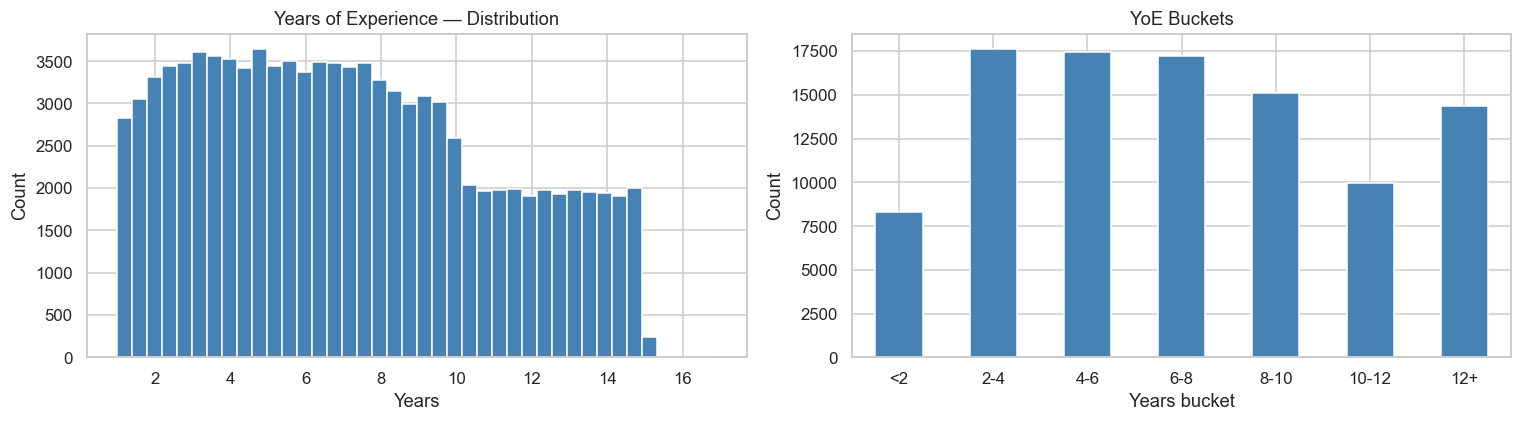

Mean YoE : 7.2
Median   : 6.8
Min / Max: 1.0 / 16.9


In [3]:
yoe = [c['profile']['years_of_experience'] for c in candidates]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(yoe, bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Years of Experience — Distribution')
axes[0].set_xlabel('Years'); axes[0].set_ylabel('Count')

buckets = pd.cut(yoe, bins=[0,2,4,6,8,10,12,20],
                 labels=['<2','2-4','4-6','6-8','8-10','10-12','12+'])
bucket_counts = buckets.value_counts().sort_index()
bucket_counts.plot(kind='bar', ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('YoE Buckets')
axes[1].set_xlabel('Years bucket'); axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

print(f'Mean YoE : {np.mean(yoe):.1f}')
print(f'Median   : {np.median(yoe):.1f}')
print(f'Min / Max: {min(yoe):.1f} / {max(yoe):.1f}')

---
## 2. Geography

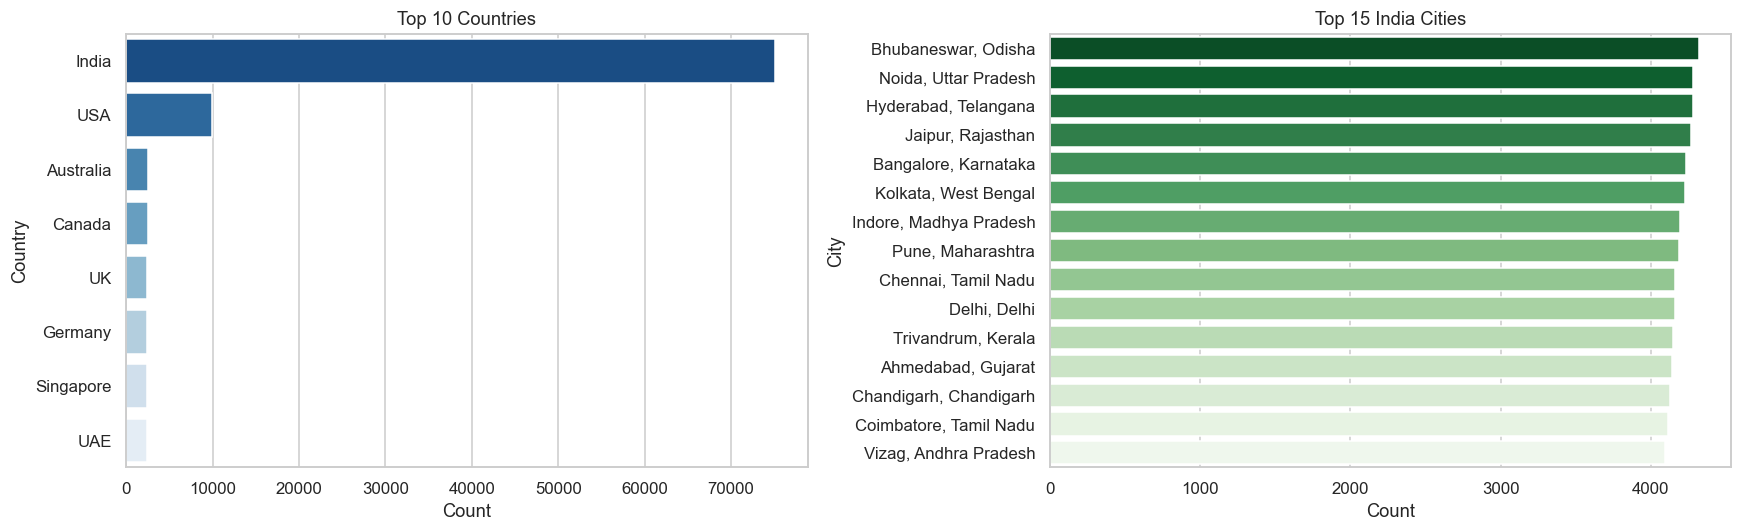

Country breakdown:
  India           75,113  (75.1%)
  USA              9,978  (10.0%)
  Australia        2,579  (2.6%)
  Canada           2,506  (2.5%)
  UK               2,472  (2.5%)
  Germany          2,469  (2.5%)
  Singapore        2,453  (2.5%)
  UAE              2,430  (2.4%)


In [4]:
countries  = Counter(c['profile']['country'] for c in candidates)
locations  = Counter(c['profile']['location'] for c in candidates)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Country
ctry_df = pd.DataFrame(countries.most_common(10), columns=['Country','Count'])
sns.barplot(data=ctry_df, x='Count', y='Country', ax=axes[0], palette='Blues_r')
axes[0].set_title('Top 10 Countries')

# India cities
india_cities = Counter(
    c['profile']['location']
    for c in candidates if c['profile']['country'] == 'India'
)
city_df = pd.DataFrame(india_cities.most_common(15), columns=['City','Count'])
sns.barplot(data=city_df, x='Count', y='City', ax=axes[1], palette='Greens_r')
axes[1].set_title('Top 15 India Cities')

plt.tight_layout()
plt.show()

n = len(candidates)
print('Country breakdown:')
for country, cnt in countries.most_common(8):
    print(f'  {country:<15} {cnt:>6,}  ({cnt/n*100:.1f}%)')

---
## 3. Titles & Role Distribution

In [5]:
titles = Counter(c['profile']['current_title'] for c in candidates)

# All titles
print(f'Unique titles: {len(titles)}')
print('\nAll titles (count desc):')
for title, cnt in titles.most_common():
    print(f'  {cnt:>6,}  {title}')

Unique titles: 47

All titles (count desc):
   5,833  Business Analyst
   5,830  HR Manager
   5,791  Mechanical Engineer
   5,764  Accountant
   5,754  Project Manager
   5,750  Customer Support
   5,744  Operations Manager
   5,727  Content Writer
   5,713  Sales Executive
   5,702  Civil Engineer
   5,689  Graphic Designer
   5,524  Marketing Manager
   3,450  Software Engineer
   2,873  Full Stack Developer
   2,836  Cloud Engineer
   2,809  Java Developer
   2,788  .NET Developer
   2,787  DevOps Engineer
   2,757  Mobile Developer
   2,738  Frontend Engineer
   2,682  QA Engineer
     764  Analytics Engineer
     744  Data Engineer
     728  Data Analyst
     704  Backend Engineer
     687  Senior Data Engineer
     653  Senior Software Engineer
     167  ML Engineer
     153  AI Research Engineer
     145  Data Scientist
     142  Senior Software Engineer (ML)
     132  Computer Vision Engineer
     131  Junior ML Engineer
     130  AI Specialist
      26  Recommendation Systems

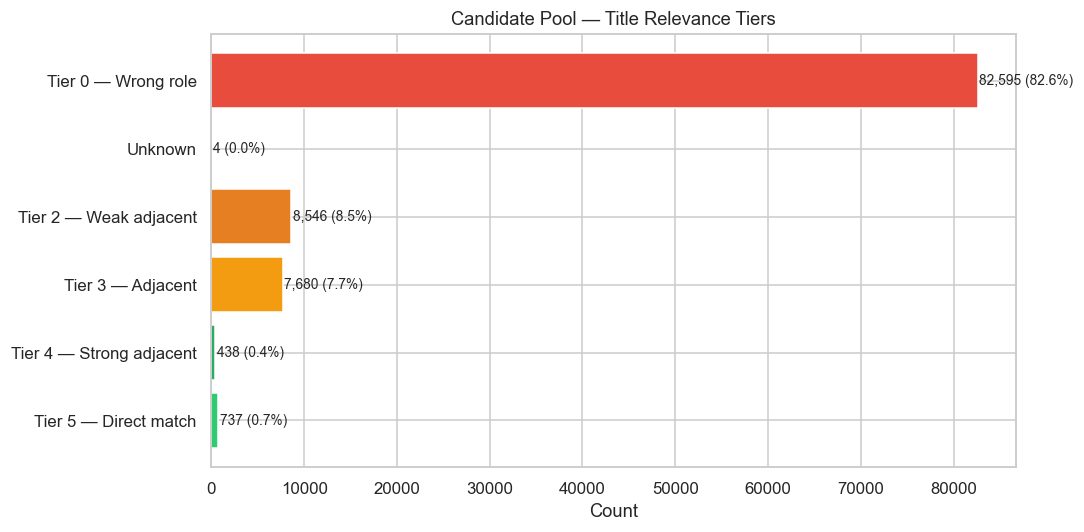

In [6]:
# Categorise titles into relevance tiers
TIER5 = {
    'senior ai engineer','ml engineer','machine learning engineer','ai engineer',
    'applied ml engineer','nlp engineer','senior nlp engineer','search engineer',
    'recommendation systems engineer','ai research engineer',
    'staff machine learning engineer','lead ai engineer','ai specialist',
    'senior machine learning engineer','junior ml engineer'
}
TIER4 = {'data scientist','senior data scientist','computer vision engineer',
         'senior software engineer (ml)'}
TIER3 = {'software engineer','senior software engineer','backend engineer',
         'full stack developer'}
TIER2 = {'data engineer','analytics engineer','data analyst',
         'senior data engineer','cloud engineer','devops engineer'}
TIER0 = {'hr manager','accountant','mechanical engineer','civil engineer',
         'content writer','marketing manager','sales executive','business analyst',
         'project manager','operations manager','customer support','graphic designer',
         'java developer','.net developer','mobile developer','frontend engineer','qa engineer'}

def get_tier(title):
    t = title.lower().strip()
    if t in TIER5: return 'Tier 5 — Direct match'
    if t in TIER4: return 'Tier 4 — Strong adjacent'
    if t in TIER3: return 'Tier 3 — Adjacent'
    if t in TIER2: return 'Tier 2 — Weak adjacent'
    if t in TIER0: return 'Tier 0 — Wrong role'
    return 'Unknown'

tier_counts = Counter(get_tier(c['profile']['current_title']) for c in candidates)

fig, ax = plt.subplots(figsize=(10, 5))
order = ['Tier 5 — Direct match','Tier 4 — Strong adjacent','Tier 3 — Adjacent',
         'Tier 2 — Weak adjacent','Unknown','Tier 0 — Wrong role']
colors = ['#2ecc71','#27ae60','#f39c12','#e67e22','#95a5a6','#e74c3c']
vals   = [tier_counts.get(o, 0) for o in order]
bars   = ax.barh(order, vals, color=colors, edgecolor='white')
for bar, val in zip(bars, vals):
    ax.text(bar.get_width() + 200, bar.get_y() + bar.get_height()/2,
            f'{val:,} ({val/n*100:.1f}%)', va='center', fontsize=9)
ax.set_title('Candidate Pool — Title Relevance Tiers')
ax.set_xlabel('Count')
plt.tight_layout()
plt.show()

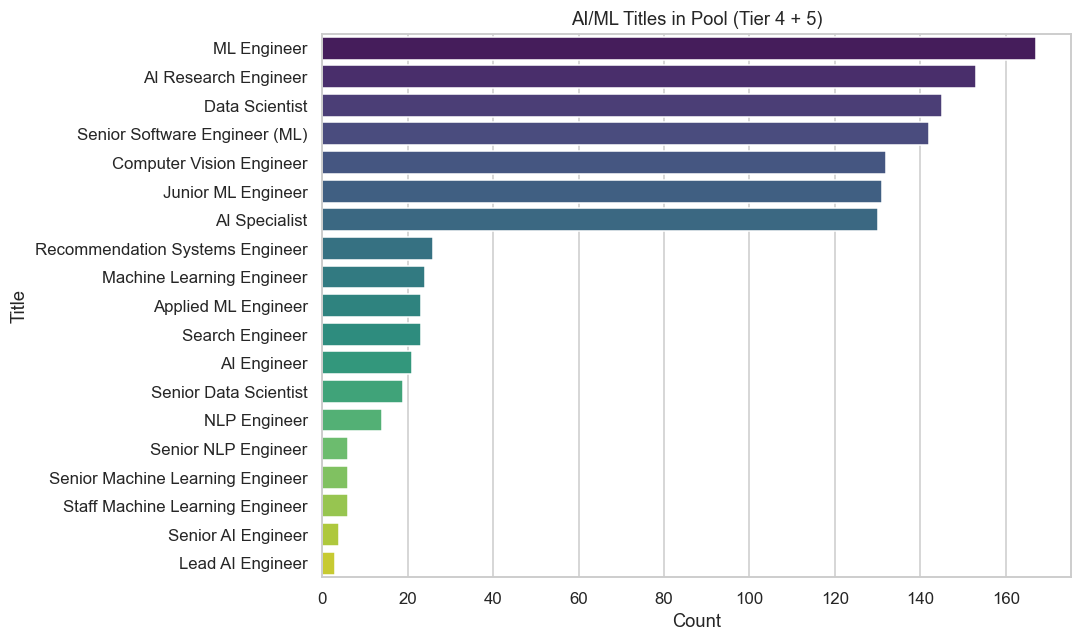


Total AI/ML candidates (Tier 4+5): 1,175
India-based AI/ML (Tier 4+5):


   148  ML Engineer
   140  AI Research Engineer
   134  Data Scientist
   126  Senior Software Engineer (ML)
   124  Junior ML Engineer
   120  Computer Vision Engineer
   119  AI Specialist
    25  Recommendation Systems Engineer
    21  Applied ML Engineer
    20  Search Engineer
    19  Machine Learning Engineer
    17  Senior Data Scientist
    16  AI Engineer
    14  NLP Engineer
     6  Senior NLP Engineer
     5  Senior Machine Learning Engineer
     5  Staff Machine Learning Engineer
     4  Senior AI Engineer
     3  Lead AI Engineer


In [7]:
# Zoom into Tier 4 + 5 (the candidates we actually care about)
ai_titles = Counter(
    c['profile']['current_title']
    for c in candidates
    if c['profile']['current_title'].lower().strip() in TIER5 | TIER4
)

ai_df = pd.DataFrame(ai_titles.most_common(), columns=['Title','Count'])
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=ai_df, x='Count', y='Title', ax=ax, palette='viridis')
ax.set_title('AI/ML Titles in Pool (Tier 4 + 5)')
plt.tight_layout()
plt.show()

print(f'\nTotal AI/ML candidates (Tier 4+5): {ai_df["Count"].sum():,}')
print(f'India-based AI/ML (Tier 4+5):')
india_ai = Counter(
    c['profile']['current_title']
    for c in candidates
    if c['profile']['current_title'].lower().strip() in TIER5 | TIER4
    and c['profile']['country'] == 'India'
)
for t, cnt in india_ai.most_common():
    print(f'  {cnt:>4}  {t}')

---
## 4. Skills Analysis

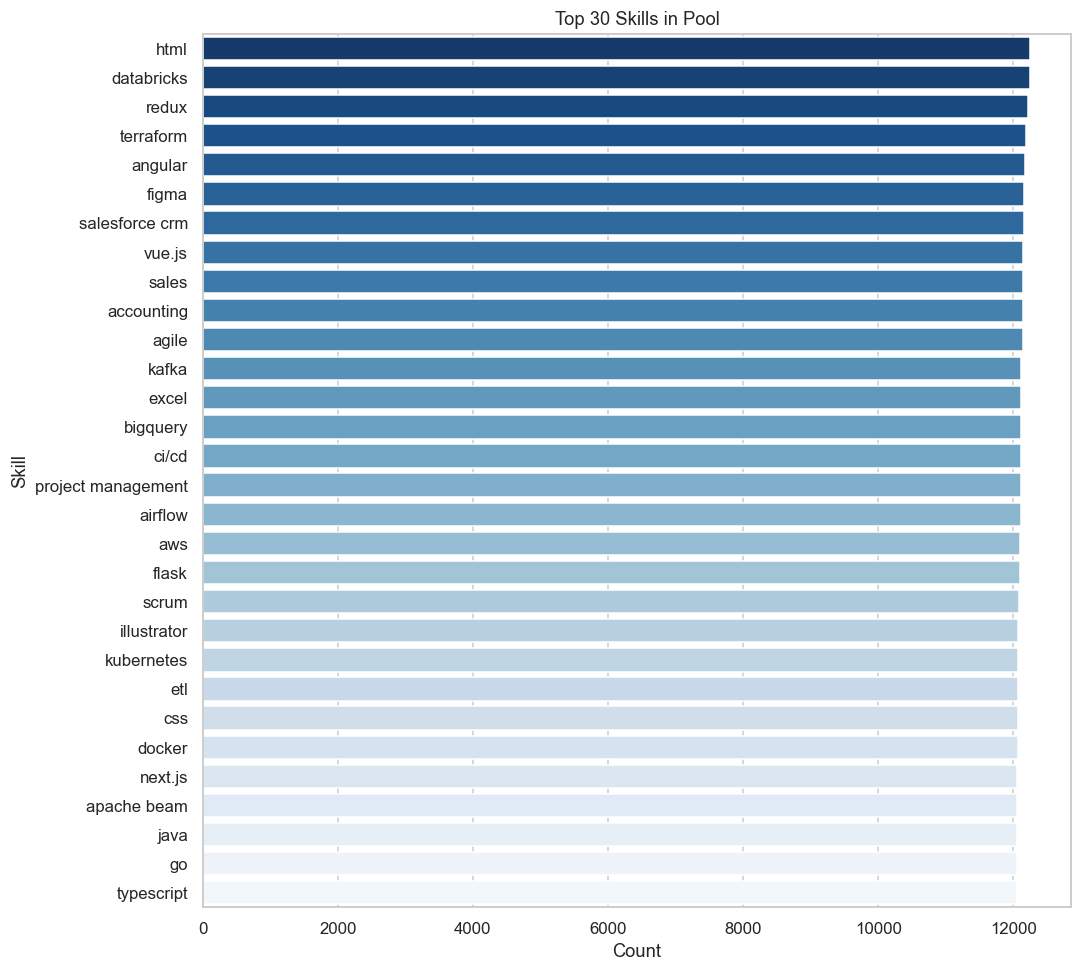

In [8]:
# All skill frequency
all_skills = Counter()
for c in candidates:
    for s in c['skills']:
        all_skills[s['name'].lower().strip()] += 1

skill_df = pd.DataFrame(all_skills.most_common(30), columns=['Skill','Count'])

fig, ax = plt.subplots(figsize=(10, 9))
sns.barplot(data=skill_df, x='Count', y='Skill', ax=ax, palette='Blues_r')
ax.set_title('Top 30 Skills in Pool')
plt.tight_layout()
plt.show()

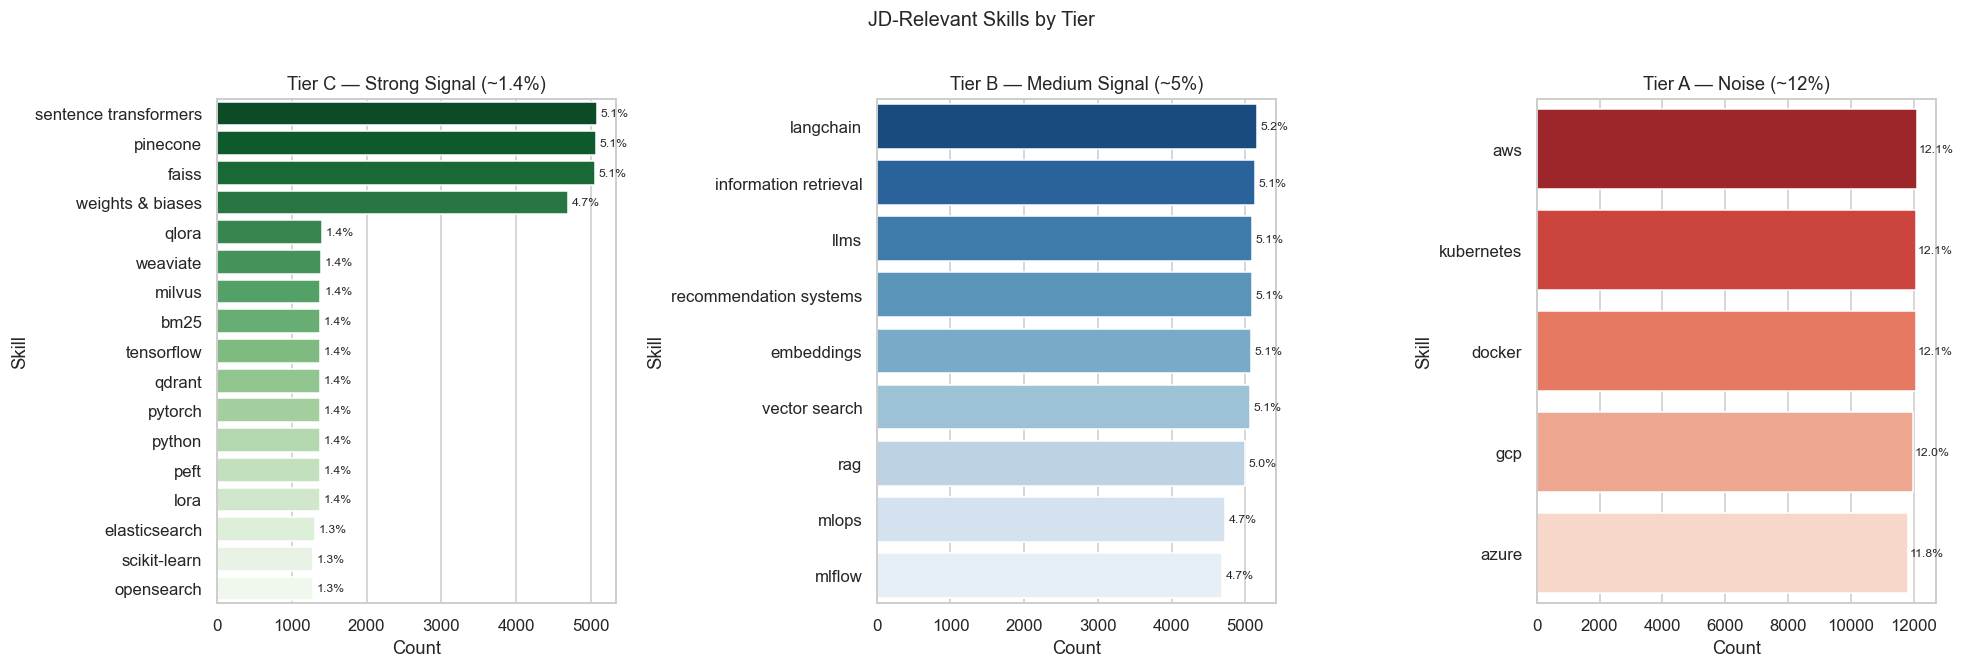

KEY INSIGHT: Tier-A skills (AWS/Docker/K8s) appear in ~12% of ALL candidates
including HR Managers and Accountants — they are noise, not signal.
Tier-C skills (~1.4%) are the real differentiators.


In [9]:
# JD-relevant skills by tier
TIER_C = {
    'faiss','pinecone','weaviate','qdrant','milvus','opensearch','elasticsearch',
    'bm25','sentence transformers','python','pytorch','tensorflow','scikit-learn',
    'lora','qlora','peft','weights & biases','wandb'
}
TIER_B = {
    'langchain','embeddings','vector search','information retrieval',
    'recommendation systems','rag','mlflow','llms','mlops',
    'hybrid search','fine-tuning','huggingface'
}
TIER_A = {'aws','gcp','azure','docker','kubernetes'}

def skill_freq(tier_set, label):
    freq = {k: all_skills[k] for k in tier_set if k in all_skills}
    df   = pd.DataFrame(sorted(freq.items(), key=lambda x: -x[1]),
                        columns=['Skill','Count'])
    df['pct'] = (df['Count'] / len(candidates) * 100).round(1)
    return df

tc = skill_freq(TIER_C, 'C'); tb = skill_freq(TIER_B, 'B'); ta = skill_freq(TIER_A, 'A')

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for df, ax, title, color in [
    (tc, axes[0], 'Tier C — Strong Signal (~1.4%)', 'Greens_r'),
    (tb, axes[1], 'Tier B — Medium Signal (~5%)',   'Blues_r'),
    (ta, axes[2], 'Tier A — Noise (~12%)',           'Reds_r'),
]:
    sns.barplot(data=df, x='Count', y='Skill', ax=ax, palette=color)
    ax.set_title(title)
    for i, (_, row) in enumerate(df.iterrows()):
        ax.text(row['Count'] + 50, i, f"{row['pct']}%", va='center', fontsize=8)

plt.suptitle('JD-Relevant Skills by Tier', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print('KEY INSIGHT: Tier-A skills (AWS/Docker/K8s) appear in ~12% of ALL candidates')
print('including HR Managers and Accountants — they are noise, not signal.')
print('Tier-C skills (~1.4%) are the real differentiators.')

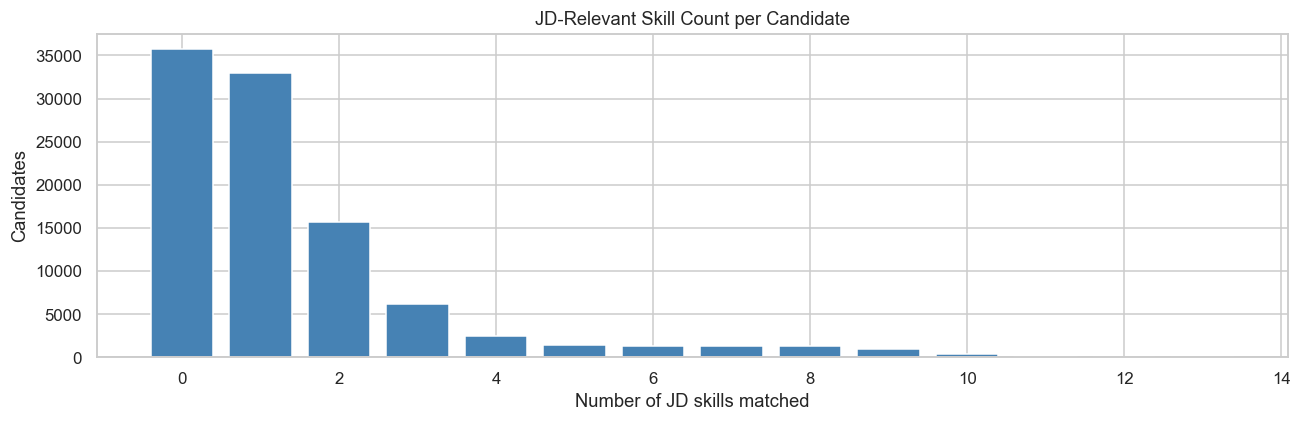

Distribution:
   0 JD skills: 35,721 candidates (35.7%)
   1 JD skills: 32,997 candidates (33.0%)
   2 JD skills: 15,680 candidates (15.7%)
   3 JD skills:  6,129 candidates (6.1%)
   4 JD skills:  2,509 candidates (2.5%)
   5 JD skills:  1,393 candidates (1.4%)
   6 JD skills:  1,322 candidates (1.3%)
   7 JD skills:  1,358 candidates (1.4%)
   8 JD skills:  1,318 candidates (1.3%)
   9 JD skills:    972 candidates (1.0%)
  10 JD skills:    446 candidates (0.4%)
  11 JD skills:    126 candidates (0.1%)
  12 JD skills:     25 candidates (0.0%)
  13 JD skills:      4 candidates (0.0%)


In [10]:
# Skill count distribution per candidate
jd_skill_counts = []
for c in candidates:
    cskills = {s['name'].lower().strip() for s in c['skills']}
    jd_match = len(cskills & (TIER_C | TIER_B | TIER_A))
    jd_skill_counts.append(jd_match)

fig, ax = plt.subplots(figsize=(12, 4))
sc = Counter(jd_skill_counts)
ax.bar(sc.keys(), sc.values(), color='steelblue', edgecolor='white')
ax.set_title('JD-Relevant Skill Count per Candidate')
ax.set_xlabel('Number of JD skills matched'); ax.set_ylabel('Candidates')
plt.tight_layout()
plt.show()

print('Distribution:')
for k in sorted(sc.keys()):
    print(f'  {k:>2} JD skills: {sc[k]:>6,} candidates ({sc[k]/n*100:.1f}%)')

---
## 5. Career Background

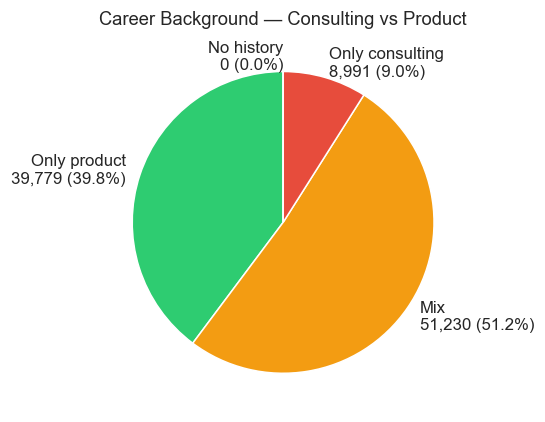

In [11]:
CONSULTING = {
    'tcs','infosys','wipro','accenture','cognizant','capgemini',
    'hcl','tech mahindra','mindtree','lti','hexaware','dxc'
}

consulting_status = []
for c in candidates:
    cos = {j['company'].lower().strip() for j in c['career_history']}
    overlap = cos & CONSULTING
    if not cos:
        consulting_status.append('No history')
    elif overlap == cos:
        consulting_status.append('Only consulting')
    elif overlap:
        consulting_status.append('Mix')
    else:
        consulting_status.append('Only product')

status_counts = Counter(consulting_status)

fig, ax = plt.subplots(figsize=(8, 4))
labels  = ['Only product','Mix','Only consulting','No history']
colors  = ['#2ecc71','#f39c12','#e74c3c','#95a5a6']
vals    = [status_counts.get(l, 0) for l in labels]
ax.pie(vals, labels=[f'{l}\n{v:,} ({v/n*100:.1f}%)' for l, v in zip(labels, vals)],
       colors=colors, startangle=90, wedgeprops=dict(edgecolor='white'))
ax.set_title('Career Background — Consulting vs Product')
plt.tight_layout()
plt.show()

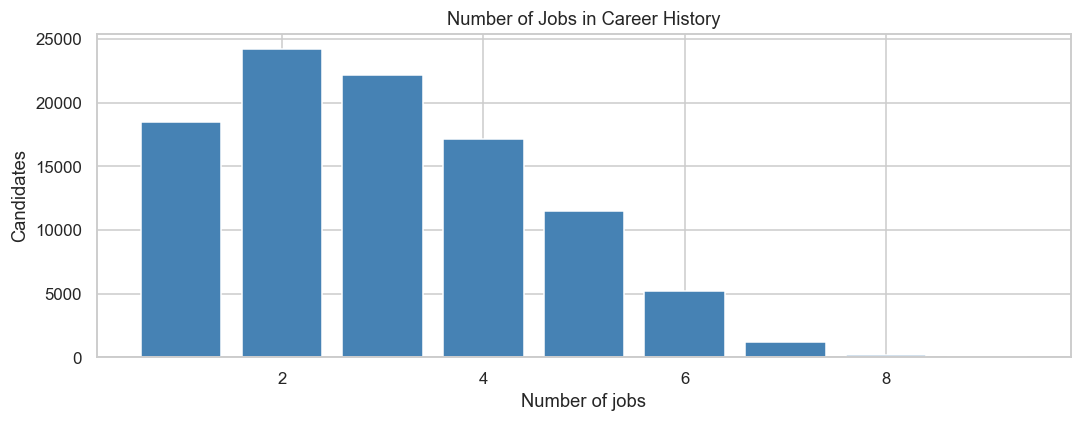

Avg career jobs: 3.0
Max career jobs: 9


In [12]:
# Career length distribution
career_lengths = [len(c['career_history']) for c in candidates]
career_counter = Counter(career_lengths)

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(career_counter.keys(), career_counter.values(), color='steelblue', edgecolor='white')
ax.set_title('Number of Jobs in Career History')
ax.set_xlabel('Number of jobs'); ax.set_ylabel('Candidates')
plt.tight_layout()
plt.show()

print(f'Avg career jobs: {np.mean(career_lengths):.1f}')
print(f'Max career jobs: {max(career_lengths)}')

---
## 6. Behavioral Signals

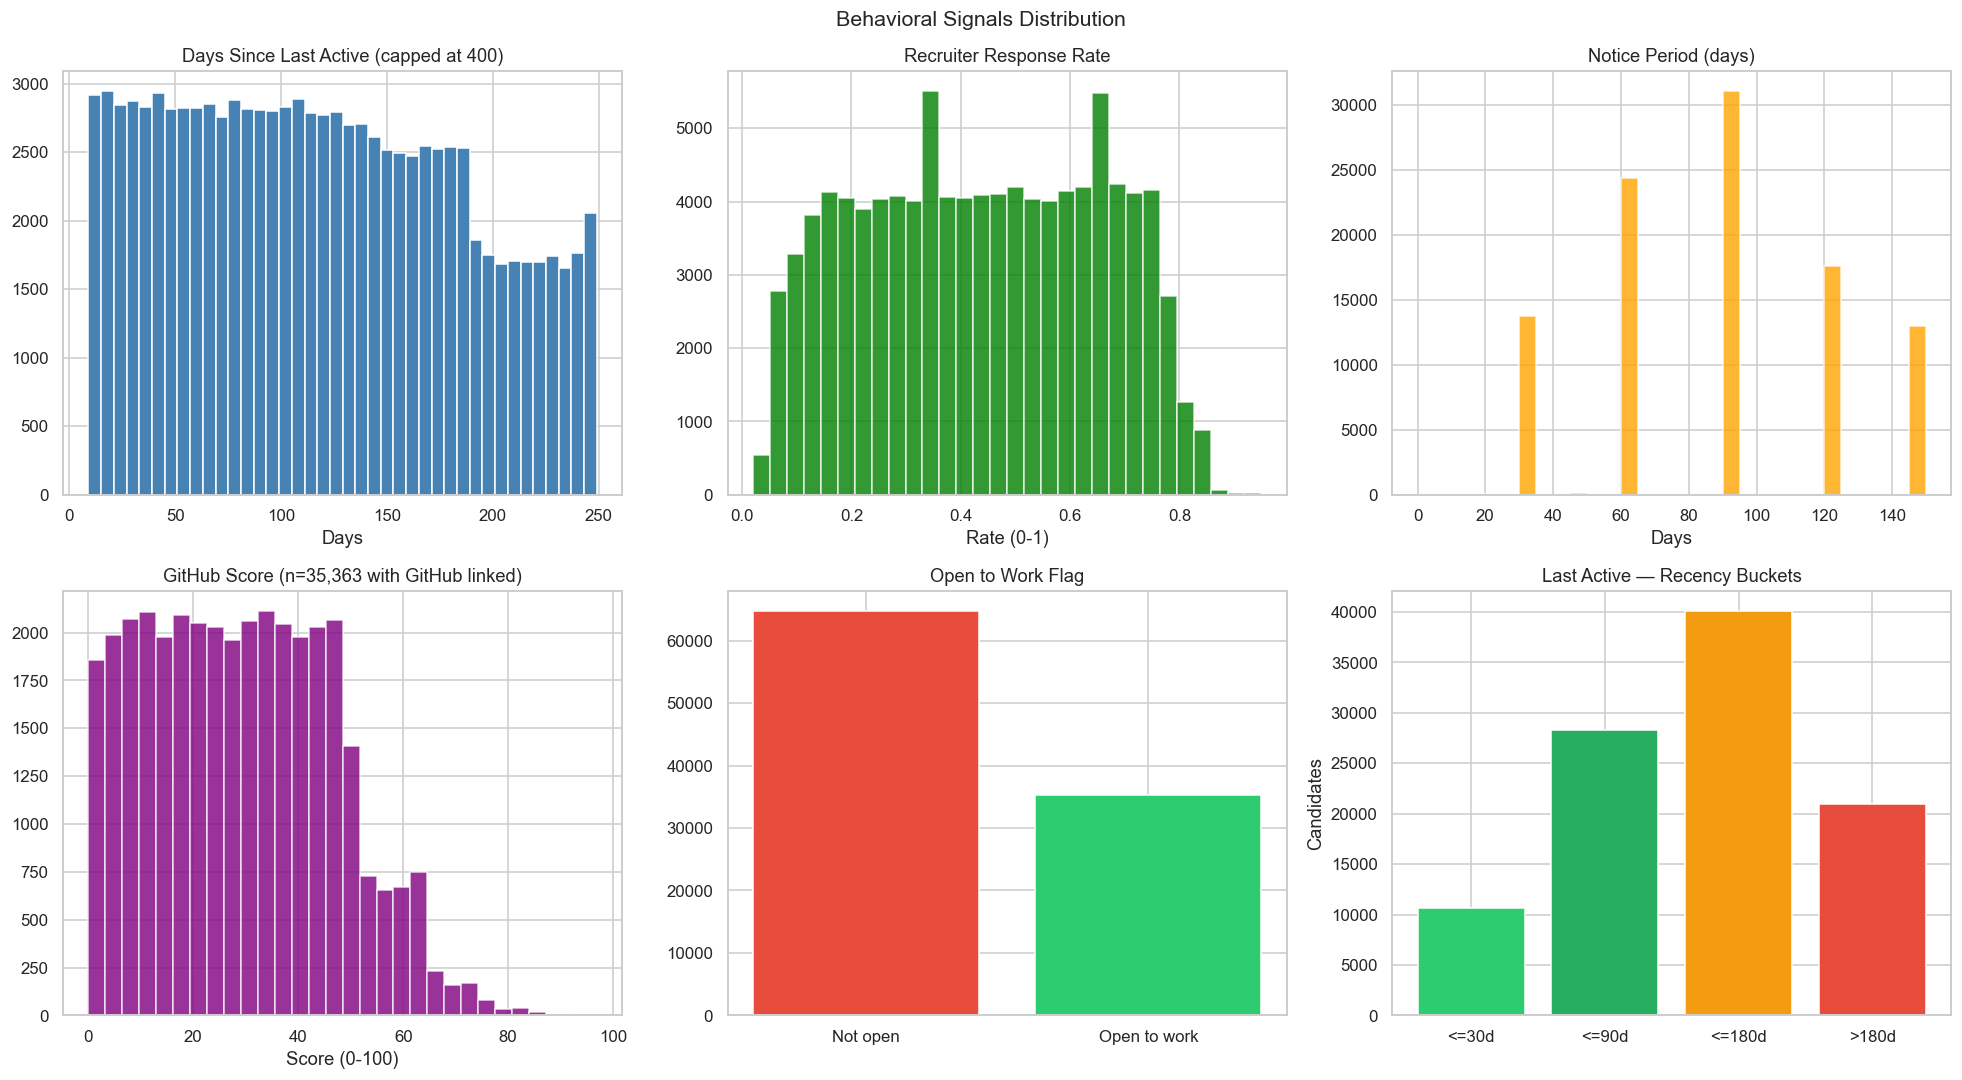

Open to work:        35,339 (35.3%)
Active <=30d:        10,677 (10.7%)
GitHub linked:       35,363 (35.4%)
Avg response rate:   43.7%
Avg notice period:   87 days


In [13]:
def days_since(s):
    try:
        return (CURRENT_DATE - datetime.strptime(s, '%Y-%m-%d')).days
    except:
        return 9999

sigs = [c['redrob_signals'] for c in candidates]

active_days    = [days_since(s.get('last_active_date','')) for s in sigs]
response_rates = [s.get('recruiter_response_rate', 0) for s in sigs]
notice_periods = [s.get('notice_period_days', 0) for s in sigs]
github_scores  = [s.get('github_activity_score', -1) for s in sigs]
open_to_work   = [s.get('open_to_work_flag', False) for s in sigs]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Last active
capped = [min(d, 400) for d in active_days]
axes[0,0].hist(capped, bins=40, color='steelblue', edgecolor='white')
axes[0,0].set_title('Days Since Last Active (capped at 400)')
axes[0,0].set_xlabel('Days')

# Response rate
axes[0,1].hist(response_rates, bins=30, color='green', edgecolor='white', alpha=0.8)
axes[0,1].set_title('Recruiter Response Rate')
axes[0,1].set_xlabel('Rate (0-1)')

# Notice period
axes[0,2].hist(notice_periods, bins=30, color='orange', edgecolor='white', alpha=0.8)
axes[0,2].set_title('Notice Period (days)')
axes[0,2].set_xlabel('Days')

# GitHub score
gh_valid = [g for g in github_scores if g >= 0]
axes[1,0].hist(gh_valid, bins=30, color='purple', edgecolor='white', alpha=0.8)
axes[1,0].set_title(f'GitHub Score (n={len(gh_valid):,} with GitHub linked)')
axes[1,0].set_xlabel('Score (0-100)')

# Open to work
otw_counts = Counter(open_to_work)
axes[1,1].bar(['Not open','Open to work'],
              [otw_counts[False], otw_counts[True]],
              color=['#e74c3c','#2ecc71'], edgecolor='white')
axes[1,1].set_title('Open to Work Flag')

# Active recency buckets
buckets = Counter()
for d in active_days:
    if d <= 30:   buckets['<=30d'] += 1
    elif d <= 90: buckets['<=90d'] += 1
    elif d <= 180:buckets['<=180d'] += 1
    else:         buckets['>180d'] += 1
bkeys = ['<=30d','<=90d','<=180d','>180d']
axes[1,2].bar(bkeys, [buckets[k] for k in bkeys],
              color=['#2ecc71','#27ae60','#f39c12','#e74c3c'], edgecolor='white')
axes[1,2].set_title('Last Active — Recency Buckets')
axes[1,2].set_ylabel('Candidates')

plt.suptitle('Behavioral Signals Distribution', fontsize=14)
plt.tight_layout()
plt.show()

print(f'Open to work:        {sum(open_to_work):,} ({sum(open_to_work)/n*100:.1f}%)')
print(f'Active <=30d:        {buckets["<=30d"]:,} ({buckets["<=30d"]/n*100:.1f}%)')
print(f'GitHub linked:       {len(gh_valid):,} ({len(gh_valid)/n*100:.1f}%)')
print(f'Avg response rate:   {np.mean(response_rates)*100:.1f}%')
print(f'Avg notice period:   {np.mean(notice_periods):.0f} days')

---
## 7. Honeypot Detection

In [14]:
def check_honeypot(c):
    profile = c['profile']
    career  = c['career_history']
    skills  = c['skills']
    reasons = []

    # Check 1: job date math (allow 2 month margin)
    for i, job in enumerate(career):
        start = datetime.strptime(job['start_date'], '%Y-%m-%d') if job['start_date'] else None
        end   = datetime.strptime(job['end_date'],   '%Y-%m-%d') if job['end_date'] else CURRENT_DATE
        if start and end:
            diff    = (end.year - start.year)*12 + (end.month - start.month)
            stated  = job['duration_months']
            if abs(diff - stated) > 2:
                reasons.append(f'date_mismatch(job {i}: calc={diff}m stated={stated}m)')
                break

    # Check 2: total career months vs profile YoE (allow 18mo slack)
    total_mo   = sum(j['duration_months'] for j in career)
    profile_mo = profile['years_of_experience'] * 12
    if total_mo > profile_mo + 18:
        reasons.append(f'yoe_mismatch(career={total_mo}m profile={profile_mo:.0f}m)')

    # Check 3: expert/advanced skills with 0 months duration (>=4)
    ez = sum(1 for s in skills
             if s['proficiency'] in ('expert','advanced')
             and s.get('duration_months', 0) == 0)
    if ez >= 4:
        reasons.append(f'skill_anomaly({ez} expert/adv with 0 months)')

    return reasons

honeypots = []
for c in candidates:
    reasons = check_honeypot(c)
    if reasons:
        honeypots.append({
            'id':      c['candidate_id'],
            'name':    c['profile']['anonymized_name'],
            'title':   c['profile']['current_title'],
            'yoe':     c['profile']['years_of_experience'],
            'country': c['profile']['country'],
            'reasons': reasons
        })

hp_df = pd.DataFrame(honeypots)
print(f'Honeypots detected: {len(honeypots)} (spec says ~80)')
print(f'Coverage estimate:  {len(honeypots)/80*100:.0f}%')
print()

# Type breakdown
type_counts = Counter()
for hp in honeypots:
    for r in hp['reasons']:
        type_counts[r.split('(')[0]] += 1

print('By detection type:')
for k, v in type_counts.items():
    print(f'  {k}: {v}')

Honeypots detected: 53 (spec says ~80)
Coverage estimate:  66%

By detection type:
  yoe_mismatch: 24
  date_mismatch: 35
  skill_anomaly: 13


In [15]:
# Show all honeypots found
print('All detected honeypots:\n')
for hp in honeypots:
    print(f"  {hp['id']} | {hp['title']:<40} | {hp['yoe']}yr | {hp['country']}")
    for r in hp['reasons']:
        print(f"    -> {r}")

All detected honeypots:

  CAND_0001610 | Machine Learning Engineer                | 3.0yr | India
    -> yoe_mismatch(career=61m profile=36m)
  CAND_0003430 | Business Analyst                         | 13.7yr | India
    -> date_mismatch(job 0: calc=15m stated=11m)
  CAND_0005291 | Business Analyst                         | 12.8yr | India
    -> date_mismatch(job 0: calc=33m stated=11m)
  CAND_0007353 | Frontend Engineer                        | 9.9yr | India
    -> date_mismatch(job 0: calc=33m stated=166m)
    -> yoe_mismatch(career=251m profile=119m)
  CAND_0007413 | Business Analyst                         | 13.3yr | India
    -> date_mismatch(job 0: calc=43m stated=16m)
  CAND_0008960 | Graphic Designer                         | 10.3yr | India
    -> date_mismatch(job 0: calc=21m stated=171m)
    -> yoe_mismatch(career=271m profile=124m)
  CAND_0010294 | .NET Developer                           | 8.0yr | India
    -> date_mismatch(job 0: calc=19m stated=144m)
    -> yoe_mismatch(

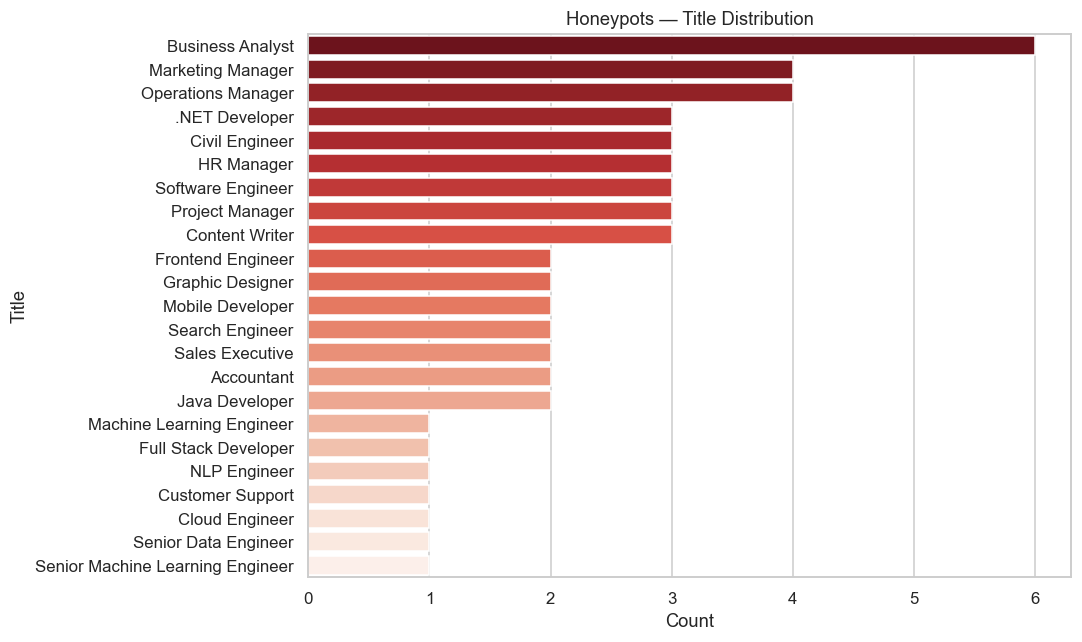

In [16]:
# Visualise honeypot distribution by title
hp_titles = Counter(h['title'] for h in honeypots)
hp_title_df = pd.DataFrame(hp_titles.most_common(), columns=['Title','Count'])

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=hp_title_df, x='Count', y='Title', ax=ax, palette='Reds_r')
ax.set_title('Honeypots — Title Distribution')
plt.tight_layout()
plt.show()

---
## 8. Keyword Stuffer Analysis

Keyword stuffers (Tier-0 title + 4+ JD skills): 5,553


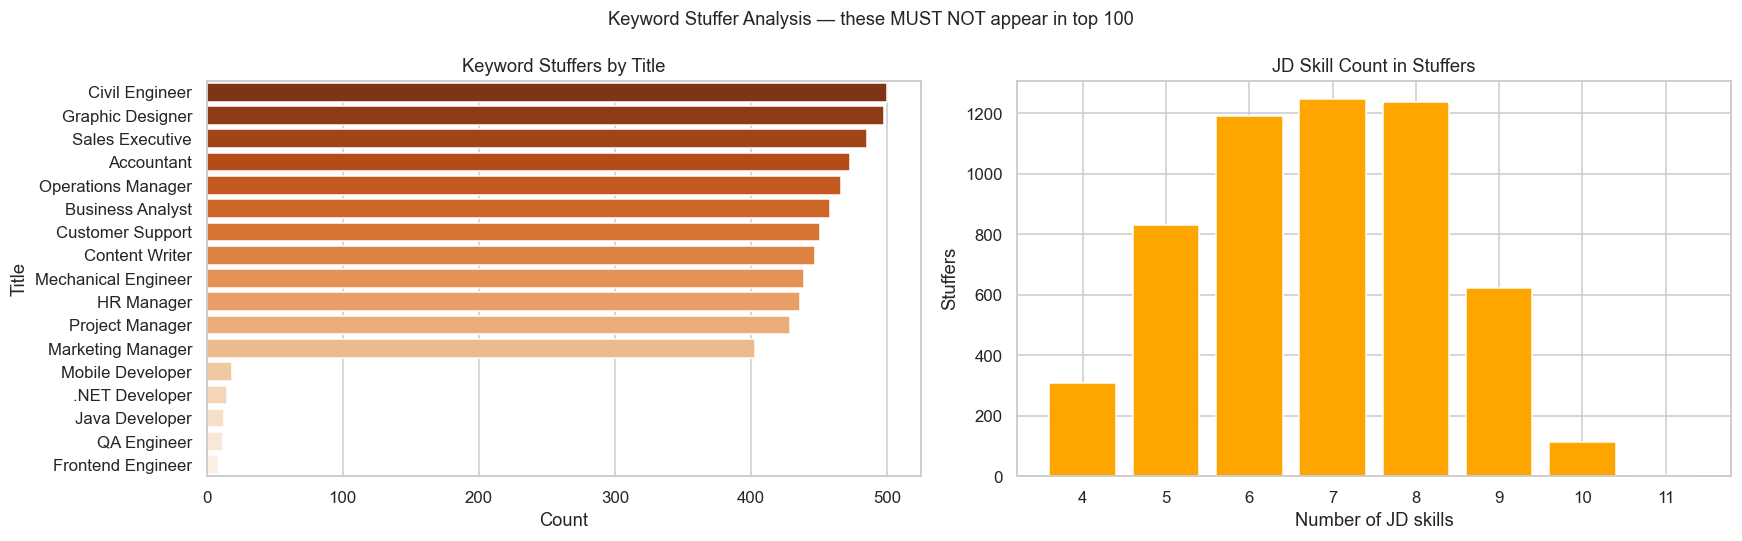


Stuffer JD skill count — mean: 6.8  max: 11


In [17]:
honeypot_ids = {h['id'] for h in honeypots}

stuffers = []
for c in candidates:
    if c['candidate_id'] in honeypot_ids:
        continue
    title = c['profile']['current_title'].lower().strip()
    if title not in TIER0:
        continue
    cskills  = {s['name'].lower().strip() for s in c['skills']}
    jd_count = len(cskills & (TIER_C | TIER_B))
    if jd_count >= 4:
        stuffers.append({
            'id':       c['candidate_id'],
            'title':    c['profile']['current_title'],
            'jd_skills':jd_count,
            'country':  c['profile']['country']
        })

print(f'Keyword stuffers (Tier-0 title + 4+ JD skills): {len(stuffers):,}')

stuffer_titles = Counter(s['title'] for s in stuffers)
st_df = pd.DataFrame(stuffer_titles.most_common(), columns=['Title','Count'])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.barplot(data=st_df, x='Count', y='Title', ax=axes[0], palette='Oranges_r')
axes[0].set_title('Keyword Stuffers by Title')

stuffer_skill_counts = Counter(s['jd_skills'] for s in stuffers)
axes[1].bar(stuffer_skill_counts.keys(), stuffer_skill_counts.values(),
            color='orange', edgecolor='white')
axes[1].set_title('JD Skill Count in Stuffers')
axes[1].set_xlabel('Number of JD skills'); axes[1].set_ylabel('Stuffers')

plt.suptitle('Keyword Stuffer Analysis — these MUST NOT appear in top 100', fontsize=12)
plt.tight_layout()
plt.show()

skills_in_stuffers = [s['jd_skills'] for s in stuffers]
print(f'\nStuffer JD skill count — mean: {np.mean(skills_in_stuffers):.1f}  max: {max(skills_in_stuffers)}')

---
## 9. Good Candidate Pool

In [18]:
good = []
for c in candidates:
    if c['candidate_id'] in honeypot_ids:
        continue
    p     = c['profile']
    title = p['current_title'].lower().strip()
    yoe   = p['years_of_experience']
    cos   = {j['company'].lower().strip() for j in c['career_history']}
    has_product = bool(cos - CONSULTING)

    if (p['country'] == 'India'
            and title in TIER5 | TIER4
            and 3 <= yoe <= 12
            and has_product):
        sig = c['redrob_signals']
        good.append({
            'id':          c['candidate_id'],
            'title':       p['current_title'],
            'yoe':         yoe,
            'location':    p['location'],
            'jd_skills':   len({s['name'].lower().strip() for s in c['skills']} & (TIER_C | TIER_B)),
            'active_days': days_since(sig.get('last_active_date','')),
            'rr':          sig.get('recruiter_response_rate', 0),
            'notice':      sig.get('notice_period_days', 90),
            'otw':         sig.get('open_to_work_flag', False),
            'github':      sig.get('github_activity_score', -1),
        })

good_df = pd.DataFrame(good)
print(f'Good candidate pool: {len(good_df):,} candidates')
print(f'(India, Tier 4/5 title, product company, 3-12yr YoE, no honeypot)')
print(f'\nWe need top 100 from this pool of {len(good_df):,}')

Good candidate pool: 1,022 candidates
(India, Tier 4/5 title, product company, 3-12yr YoE, no honeypot)

We need top 100 from this pool of 1,022


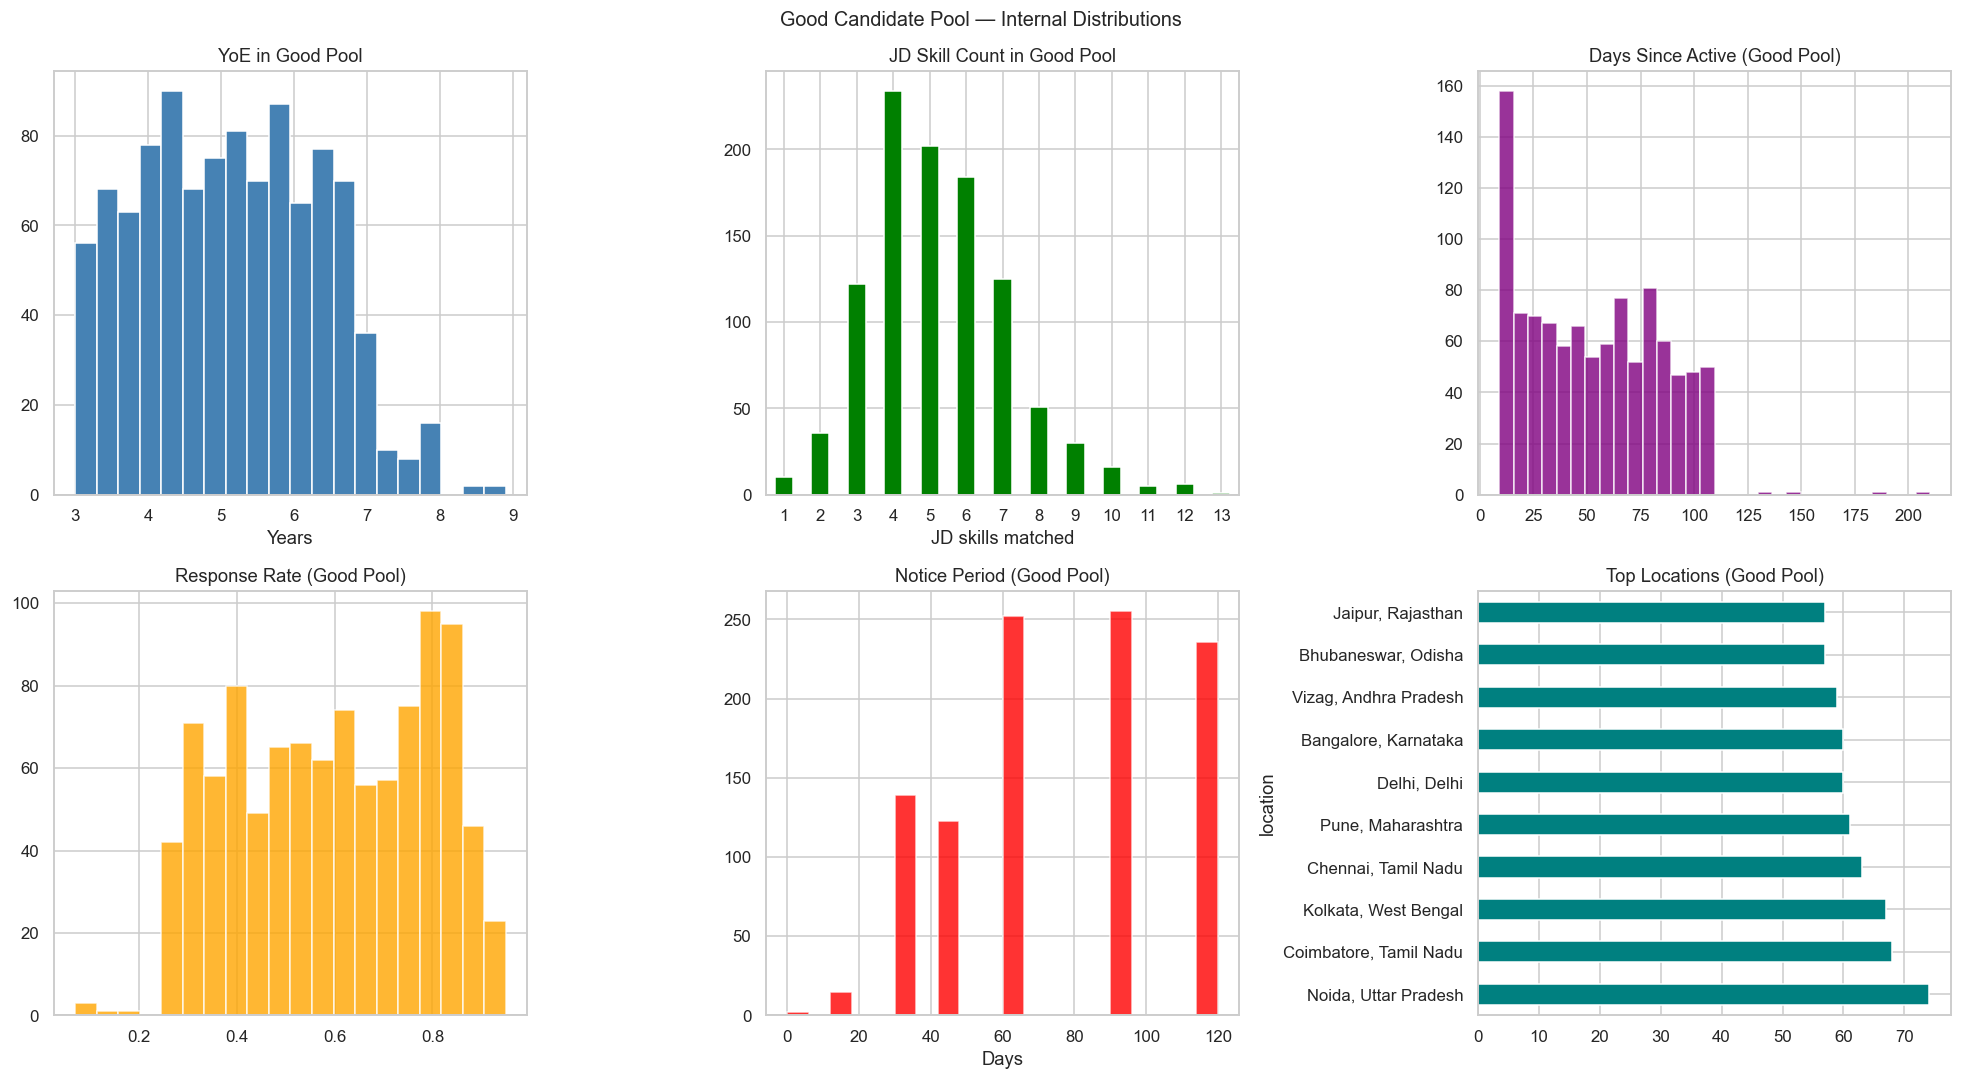

           yoe  jd_skills  active_days       rr   notice
count  1022.00    1022.00      1022.00  1022.00  1022.00
mean      5.12       5.24        53.31     0.60    74.68
std       1.23       1.91        30.94     0.20    32.06
min       3.00       1.00         9.00     0.07     0.00
25%       4.10       4.00        26.00     0.42    45.00
50%       5.10       5.00        52.00     0.60    60.00
75%       6.07       6.00        78.00     0.78    90.00
max       8.90      13.00       210.00     0.95   120.00


In [19]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# YoE
axes[0,0].hist(good_df['yoe'], bins=20, color='steelblue', edgecolor='white')
axes[0,0].set_title('YoE in Good Pool')
axes[0,0].set_xlabel('Years')

# JD skills
good_df['jd_skills'].value_counts().sort_index().plot(kind='bar', ax=axes[0,1], color='green')
axes[0,1].set_title('JD Skill Count in Good Pool')
axes[0,1].set_xlabel('JD skills matched'); axes[0,1].tick_params(axis='x', rotation=0)

# Active days
axes[0,2].hist(good_df['active_days'].clip(upper=300), bins=30, color='purple', edgecolor='white', alpha=0.8)
axes[0,2].set_title('Days Since Active (Good Pool)')

# Response rate
axes[1,0].hist(good_df['rr'], bins=20, color='orange', edgecolor='white', alpha=0.8)
axes[1,0].set_title('Response Rate (Good Pool)')

# Notice
axes[1,1].hist(good_df['notice'], bins=20, color='red', edgecolor='white', alpha=0.8)
axes[1,1].set_title('Notice Period (Good Pool)')
axes[1,1].set_xlabel('Days')

# Top locations
loc_counts = good_df['location'].value_counts().head(10)
loc_counts.plot(kind='barh', ax=axes[1,2], color='teal')
axes[1,2].set_title('Top Locations (Good Pool)')

plt.suptitle('Good Candidate Pool — Internal Distributions', fontsize=13)
plt.tight_layout()
plt.show()

print(good_df[['yoe','jd_skills','active_days','rr','notice']].describe().round(2))

---
## 10. Key Takeaways

In [20]:
print('=' * 60)
print('KEY TAKEAWAYS FOR SCORING DESIGN')
print('=' * 60)

tier0_count = sum(1 for c in candidates
                  if c['profile']['current_title'].lower().strip() in TIER0)

print(f"""
1. SCALE OF THE PROBLEM
   Total candidates  : {len(candidates):,}
   Wrong-role titles : {tier0_count:,} ({tier0_count/n*100:.1f}%) — keyword stuffer territory
   AI/ML titles      : {sum(ai_titles.values()):,} ({sum(ai_titles.values())/n*100:.1f}%)
   Good pool (India) : {len(good_df):,} — we need top 100 from here
   Honeypots found   : {len(honeypots)} (spec ~80, we catch ~{len(honeypots)/80*100:.0f}%)

2. SKILL DATA IS POISONED
   AWS/Docker/K8s appear in ~12% of ALL candidates (HR Mgrs, Accountants etc)
   Real signal skills (Python, FAISS, Qdrant) appear in only ~1.4%
   Keyword count alone will rank stuffers above real engineers

3. TITLE IS THE STRONGEST GATE
   Without a title filter, any skill-based system gets overwhelmed
   Title must act as a multiplier, not just one signal among many

4. BEHAVIORAL SIGNALS DISCRIMINATE
   Good pool avg response rate : {good_df['rr'].mean()*100:.1f}%  (pool avg {np.mean(response_rates)*100:.1f}%)
   Good pool open-to-work      : {good_df['otw'].mean()*100:.1f}%  (pool avg {sum(open_to_work)/n*100:.1f}%)
   Good pool avg active days   : {good_df['active_days'].mean():.0f}d  (pool avg {np.mean(active_days):.0f}d)

5. NOTICE PERIOD IS A SOFT PENALTY
   {(good_df['notice'] <= 30).mean()*100:.1f}% of good pool has <=30d notice (JD preference)
   Mean notice in good pool: {good_df['notice'].mean():.0f}d
   Cannot hard-cutoff — too few candidates with short notice

6. HONEYPOT RISK
   We detect {len(honeypots)}/80 (~{len(honeypots)/80*100:.0f}%)
   >10 in top 100 = DISQUALIFIED
   Must keep improving detection through each phase
""")
print('=' * 60)
print('EDA COMPLETE — move to 02_rule_based.ipynb')
print('=' * 60)

KEY TAKEAWAYS FOR SCORING DESIGN



1. SCALE OF THE PROBLEM
   Total candidates  : 100,000
   Wrong-role titles : 82,595 (82.6%) — keyword stuffer territory
   AI/ML titles      : 1,175 (1.2%)
   Good pool (India) : 1,022 — we need top 100 from here
   Honeypots found   : 53 (spec ~80, we catch ~66%)

2. SKILL DATA IS POISONED
   AWS/Docker/K8s appear in ~12% of ALL candidates (HR Mgrs, Accountants etc)
   Real signal skills (Python, FAISS, Qdrant) appear in only ~1.4%
   Keyword count alone will rank stuffers above real engineers

3. TITLE IS THE STRONGEST GATE
   Without a title filter, any skill-based system gets overwhelmed
   Title must act as a multiplier, not just one signal among many

4. BEHAVIORAL SIGNALS DISCRIMINATE
   Good pool avg response rate : 59.6%  (pool avg 43.7%)
   Good pool open-to-work      : 65.7%  (pool avg 35.3%)
   Good pool avg active days   : 53d  (pool avg 118d)

5. NOTICE PERIOD IS A SOFT PENALTY
   15.3% of good pool has <=30d notice (JD preference)
   Mean notice in good pool: 75d
   Ca